<a href="https://colab.research.google.com/github/M-marshiro/Fliprobo-Projects/blob/main/Extraproject.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Bonus Assignment: Image Classification with a Pretrained Model (ResNet50)


In [2]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("PyTorch version:", torch.__version__)
print("Device:", device)
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
Device: cuda
GPU: Tesla T4


In [3]:
import torch.nn.functional as F
from torchvision import models
from PIL import Image
import requests
from io import BytesIO
import matplotlib.pyplot as plt

In [4]:
# Load ImageNet-pretrained weights
weights = models.ResNet50_Weights.DEFAULT
model = models.resnet50(weights=weights)
model = model.to(device)
model.eval()  # inference mode (disables dropout / batchnorm updates)

# Standard preprocessing that matches the weights (resize, center crop 224, normalize)
preprocess = weights.transforms()

# Names of the 1000 ImageNet classes
class_names = weights.meta["categories"]

print("Loaded ResNet50 with", len(class_names), "classes")
print(preprocess)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 126MB/s]


Loaded ResNet50 with 1000 classes
ImageClassification(
    crop_size=[224]
    resize_size=[232]
    mean=[0.485, 0.456, 0.406]
    std=[0.229, 0.224, 0.225]
    interpolation=InterpolationMode.BILINEAR
)


In [5]:
HEADERS = {"User-Agent": "Mozilla/5.0 (Colab image classification assignment)"}

def load_image_from_url(url):
    response = requests.get(url, headers=HEADERS, timeout=15)
    response.raise_for_status()
    return Image.open(BytesIO(response.content)).convert("RGB")

image_urls = {
    "Dog":    "https://github.com/pytorch/hub/raw/master/images/dog.jpg",
    "Cat":    "https://upload.wikimedia.org/wikipedia/commons/4/4d/Cat_November_2010-1a.jpg",
    "Pug":    "https://upload.wikimedia.org/wikipedia/commons/f/f0/Mops_oct09_cropped2.jpg",
    "Banana": "https://upload.wikimedia.org/wikipedia/commons/8/8a/Banana-Single.jpg",
}

images = {}
for name, url in image_urls.items():
    try:
        images[name] = load_image_from_url(url)
        print(f"✅ Loaded: {name}")
    except Exception as e:
        print(f"⚠️ Could not load {name}: {e}")

print(f"\nTotal images: {len(images)}")

✅ Loaded: Dog
✅ Loaded: Cat
✅ Loaded: Pug
✅ Loaded: Banana

Total images: 4


In [6]:
def predict_top5(img):
    input_tensor = preprocess(img).unsqueeze(0).to(device)  # add batch dimension
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = F.softmax(outputs[0], dim=0)
    top5_prob, top5_idx = torch.topk(probs, 5)
    return [(class_names[i], p.item() * 100) for i, p in zip(top5_idx.tolist(), top5_prob)]

===== Dog =====
Samoyed: 43.66%
white wolf: 2.11%
Pomeranian: 1.32%
Great Pyrenees: 0.80%
Eskimo dog: 0.59%



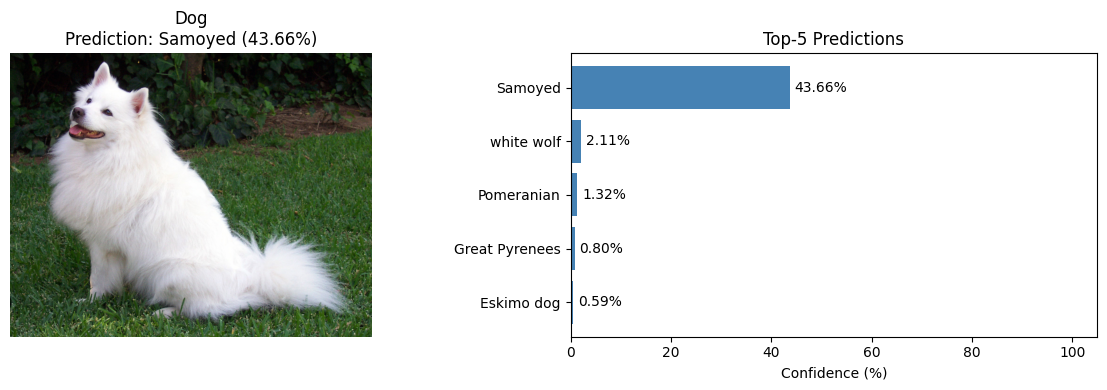

===== Cat =====
tiger cat: 22.91%
tabby: 13.23%
Egyptian cat: 7.40%
lynx: 0.39%
leopard: 0.31%



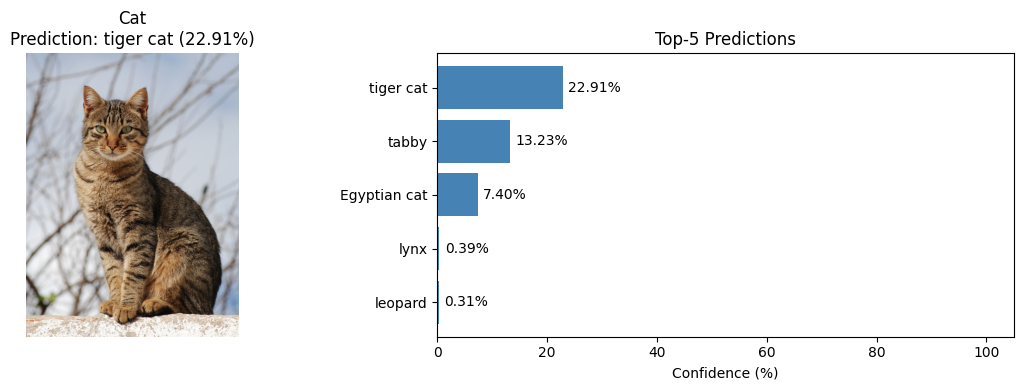

===== Pug =====
pug: 33.18%
bull mastiff: 1.27%
chow: 0.73%
Norwegian elkhound: 0.64%
Brabancon griffon: 0.63%



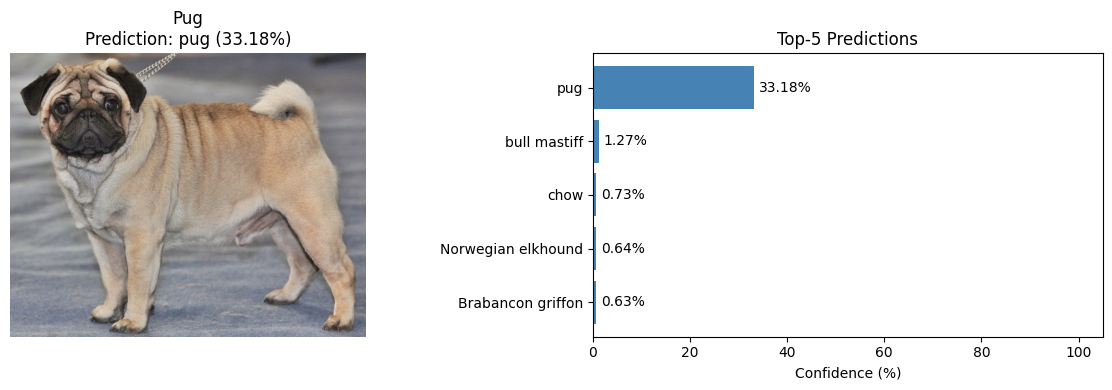

===== Banana =====
banana: 47.48%
grocery store: 1.39%
orange: 1.18%
lemon: 0.56%
gondola: 0.50%



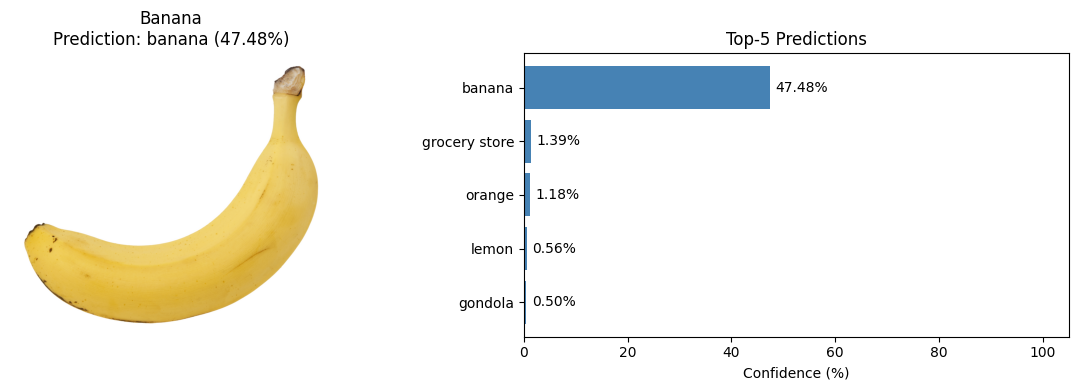

In [7]:
def show_prediction(name, img):
    results = predict_top5(img)

    # Print results as text (same format as the assignment's example output)
    print(f"===== {name} =====")
    for label, prob in results:
        print(f"{label}: {prob:.2f}%")
    print()

    # Show the image next to a bar chart of the Top-5 probabilities
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].imshow(img)
    axes[0].set_title(f"{name}\nPrediction: {results[0][0]} ({results[0][1]:.2f}%)")
    axes[0].axis("off")

    labels = [r[0] for r in results][::-1]
    values = [r[1] for r in results][::-1]
    bars = axes[1].barh(labels, values, color="steelblue")
    axes[1].set_xlabel("Confidence (%)")
    axes[1].set_title("Top-5 Predictions")
    axes[1].set_xlim(0, 105)
    for bar, v in zip(bars, values):
        axes[1].text(v + 1, bar.get_y() + bar.get_height() / 2, f"{v:.2f}%", va="center")

    plt.tight_layout()
    plt.show()

for name, img in images.items():
    show_prediction(name, img)

Saving 405420900_1999995760399869_1841278332965817471_n.jpg to 405420900_1999995760399869_1841278332965817471_n.jpg
===== 405420900_1999995760399869_1841278332965817471_n.jpg =====
jean: 37.45%
pajama: 11.80%
Loafer: 5.95%
sock: 2.65%
jersey: 1.63%



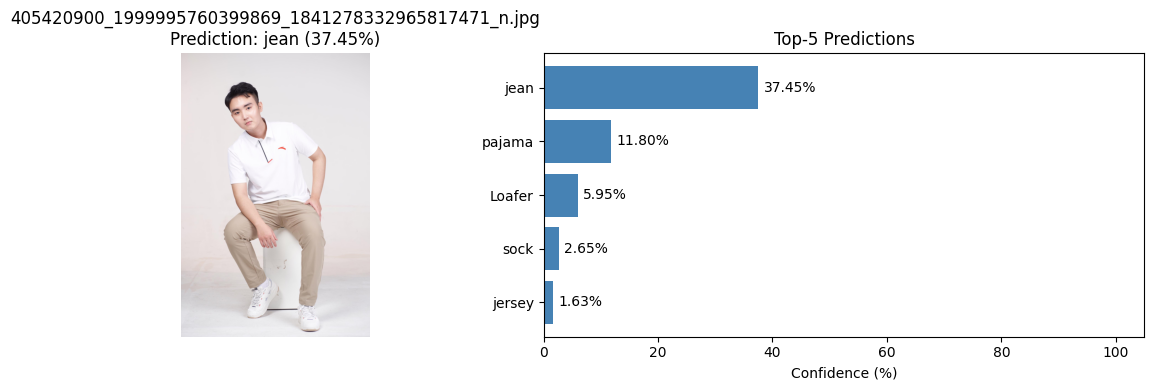

In [8]:
from google.colab import files

uploaded = files.upload()
for filename, data in uploaded.items():
    img = Image.open(BytesIO(data)).convert("RGB")
    show_prediction(filename, img)

## Discussion
- The ResNet50 model pretrained on ImageNet (1000 classes) correctly identifies common objects with high confidence.
- The Top-2 to Top-5 predictions are usually visually similar classes (e.g., related dog breeds), showing that the model has learned meaningful semantic features.
- The model can only recognize the 1000 ImageNet classes, so objects outside those classes are assigned to the closest matching class.